<a href="https://colab.research.google.com/github/Bookas1468/data-science-google-colab/blob/main/projects/LukaCookU8proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
!pip install git+https://github.com/pymc-devs/pymc-bart.git
import pymc_bart as pmb
import seaborn as sns
import graphviz as gv

  Cloning https://github.com/pymc-devs/pymc-bart.git to /tmp/pip-req-build-p7rlohqp
  Running command git clone --filter=blob:none --quiet https://github.com/pymc-devs/pymc-bart.git /tmp/pip-req-build-p7rlohqp
  Resolved https://github.com/pymc-devs/pymc-bart.git to commit 433192a477a4e2cbc2c05f9a0e6a4820ef19700c
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
!pip install pymc-bart
import pymc_bart as pmb

In [ ]:
from sklearn import tree

In [ ]:
data = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/refs/heads/main/Data/counties.csv')

In [ ]:
data.columns.values # to see the things in dataset

array(['name', 'fips', 'state', 'land_area (km^2)', 'area (km^2)',
       'longitude (deg)', 'latitude (deg)', 'noaa/prcp', 'noaa/snow',
       'noaa/temp', 'noaa/altitude', 'noaa/temp-jan', 'noaa/temp-apr',
       'noaa/temp-jul', 'noaa/temp-oct', 'zip-codes',
       'race/non_hispanic_white_alone_male',
       'race/non_hispanic_white_alone_female', 'race/black_alone_male',
       'race/black_alone_female', 'race/asian_alone_male',
       'race/asian_alone_female', 'race/hispanic_male',
       'race/hispanic_female', 'age/0-4', 'age/5-9', 'age/10-14',
       'age/15-19', 'age/20-24', 'age/25-29', 'age/30-34', 'age/35-39',
       'age/40-44', 'age/45-49', 'age/50-54', 'age/55-59', 'age/60-64',
       'age/65-69', 'age/70-74', 'age/75-79', 'age/80-84', 'age/85+',
       'male', 'female', 'population/2010', 'population/2011',
       'population/2012', 'population/2013', 'population/2014',
       'population/2015', 'population/2016', 'population/2017',
       'population/2018', 'populati

this just removes anything with blank data and makes the dem vote a percentage instead of a flat number so I can actually use it

In [ ]:
data_old = data
data = data.dropna() # remove anything missing a column

In [ ]:
data.insert(data.shape[1], "elections/2020/dem2", data['elections/2020/dem']/data['population/2019']) #makes democratic vote percentage instead of flat, much more useful
data.drop(["elections/2020/dem"],axis=1,inplace=True)

/tmp/ipykernel_11678/1777700776.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(["elections/2020/dem"],axis=1,inplace=True)


initializes a new variable called stats that contains only the columns i want my model to be based off

In [ ]:
clmn_list = ['name','state','population/2019','edu/bachelors+', 'poverty-rate', 'cost-of-living/living_wage',
       'cost-of-living/food_costs', 'cost-of-living/medical_costs',
       'cost-of-living/housing_costs', 'cost-of-living/tax_costs','avg_income','elections/2020/dem2',] #the columns i will be using
stats =  data.loc[:,clmn_list]

pair plot, looks pretty good

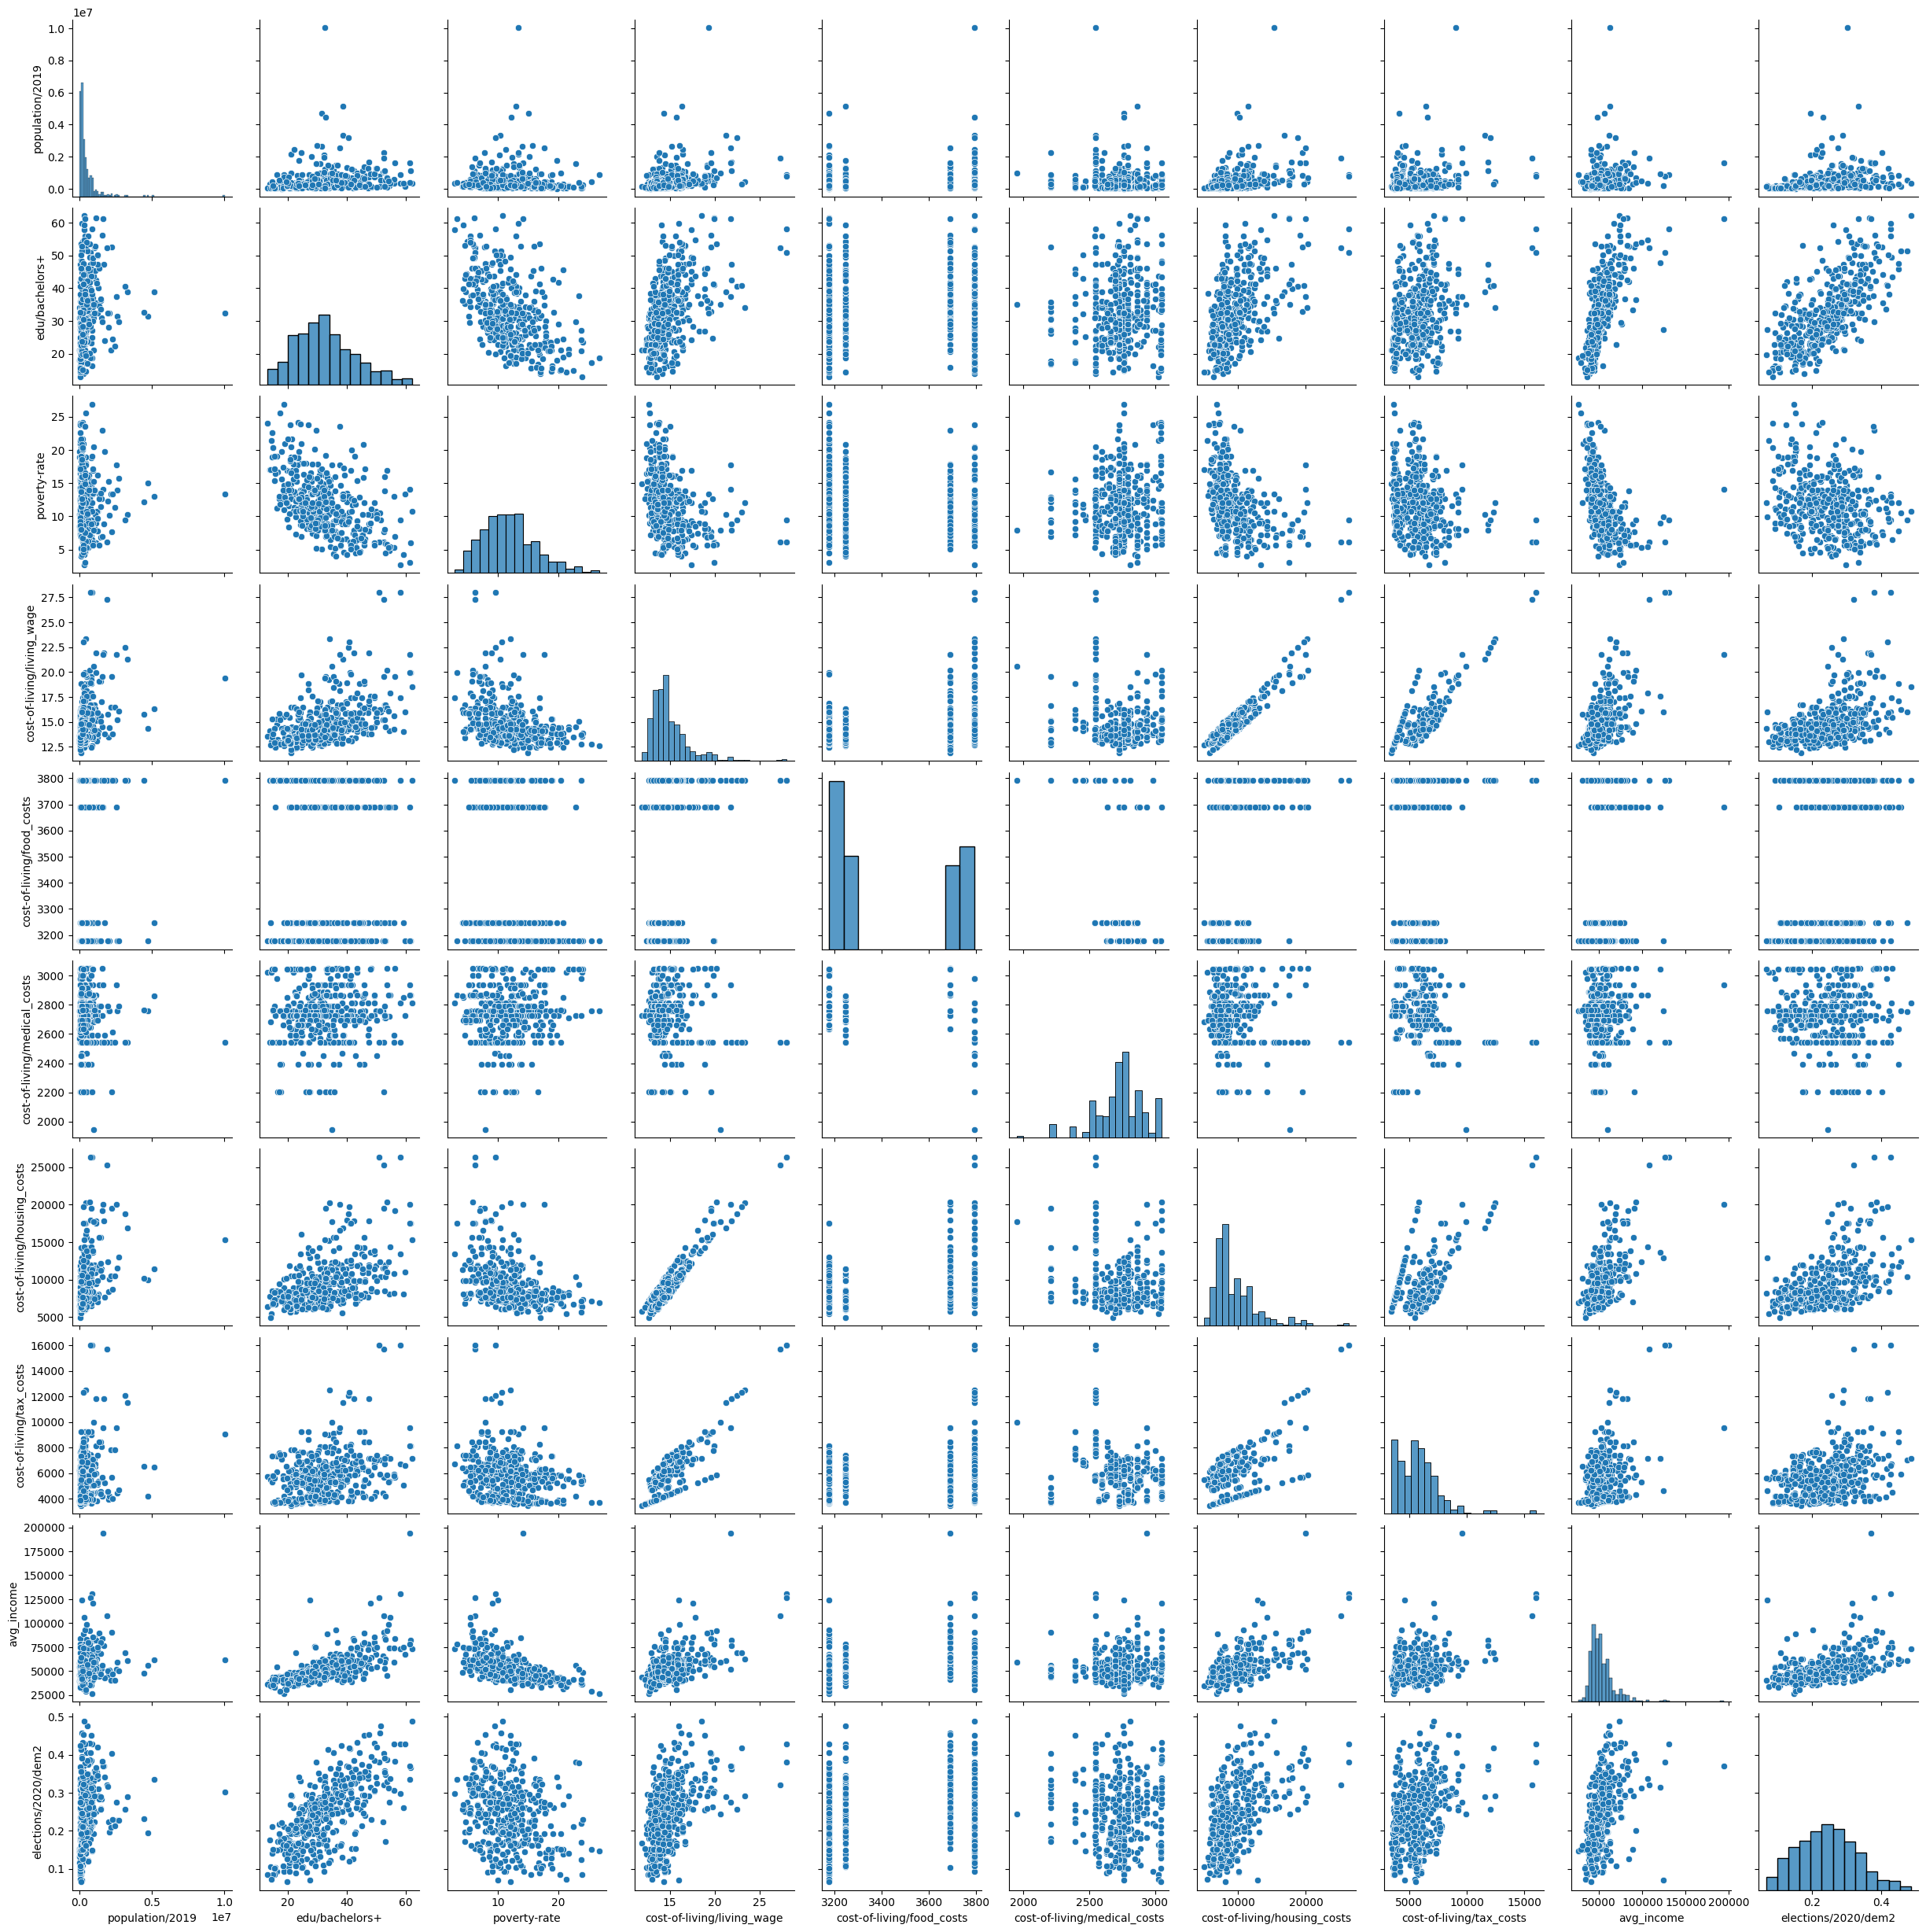

In [ ]:
sns.pairplot(stats)

Causal diagram explanation:

Education improves average income, though there are confounding variables between them that don't exist in the data it should still work. Educated people statistically vote more democratic so it would influence that, and theoretically more educated people means healthcare will be more readily available and thus cheaper.

A higher population should increase housing costs since housing is more valuable with more people that need it.

Typically Democrat policies include things like welfare, which would reduce medical costs and increase taxes.

All of the CoL variables will impact living wage and poverty rate, while housing cost also affects tax rate since property tax exists.

Living wage will affect average income, since people who makes less than it will be pushed to move. A higher income, then, will increase taxes, furter increasing the living wage. However, this cycle will eventually taper off as the increase in the living wage is smaller each time.

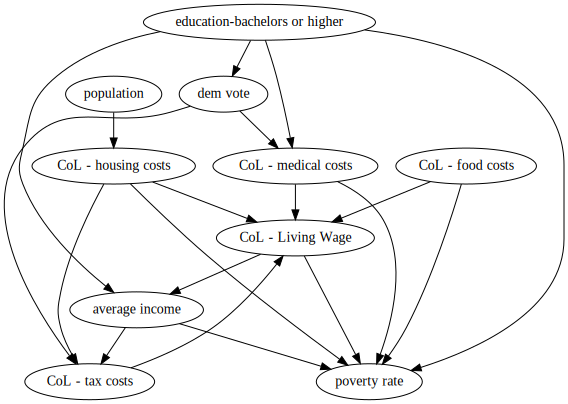

In [ ]:
causal = gv.Digraph(name="countiesCOL")

causal.node('p',"population")
causal.node('b',"education-bachelors or higher")
causal.node('v',"poverty rate")
causal.node('w',"CoL - Living Wage")
causal.node('f',"CoL - food costs")
causal.node('m',"CoL - medical costs")
causal.node('o',"CoL - housing costs")
causal.node('t',"CoL - tax costs")
causal.node('a',"average income")
causal.node('d',"dem vote")

causal.edges(['po','bv','bm','ba','wv','fw','mw','ow','tw','at','ot','wa','mv','fv','av','ov','dt','bd','dm'])

causal

time for the actual data frame

In [ ]:
#Combine all my estimator variables into one dataframe
X = stats[[
             'population/2019','edu/bachelors+', 'cost-of-living/living_wage',
       'cost-of-living/food_costs', 'cost-of-living/medical_costs',
       'cost-of-living/housing_costs', 'cost-of-living/tax_costs','avg_income','elections/2020/dem2'
             ]]
#Define my estimand as Y
Y = stats['poverty-rate']

left this as default and it worked pretty good so i'm leaving it like that

In [ ]:
with pm.Model() as model_counties:
    s = pm.HalfNormal('s',20) #sigma = 20 is a blind guess
    μ_ = pmb.BART("μ_", X, np.log(Y), m=50) #log around Y
    μ = pm.Deterministic("μ",pm.math.exp(μ_)) #exp it all once BART is done
    y = pm.Gamma("y", mu=μ, sigma=s,  observed=Y) #likelihood
    idata_counties = pm.sample(compute_convergence_checks=False)

Output()

In [ ]:
pm.sample_posterior_predictive(idata_counties,model_counties, extend_inferencedata=True)

Output()

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

the model is a pretty good fit, fails to capture a few minor dips and blips but gets the general trend very well

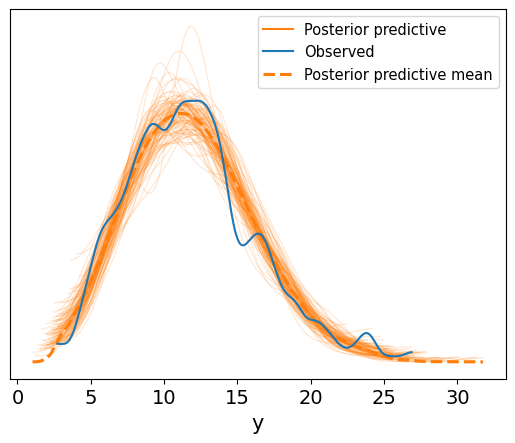

In [ ]:
ax = az.plot_ppc(idata_counties, num_pp_samples=100, colors=["C1", "C0", "C1"])

array([<Axes: xlabel='population/2019'>, <Axes: xlabel='edu/bachelors+'>,
       <Axes: xlabel='cost-of-living/living_wage'>,
       <Axes: xlabel='cost-of-living/food_costs'>,
       <Axes: xlabel='cost-of-living/medical_costs'>,
       <Axes: xlabel='cost-of-living/housing_costs'>,
       <Axes: xlabel='cost-of-living/tax_costs'>,
       <Axes: xlabel='avg_income'>, <Axes: xlabel='elections/2020/dem2'>],
      dtype=object)

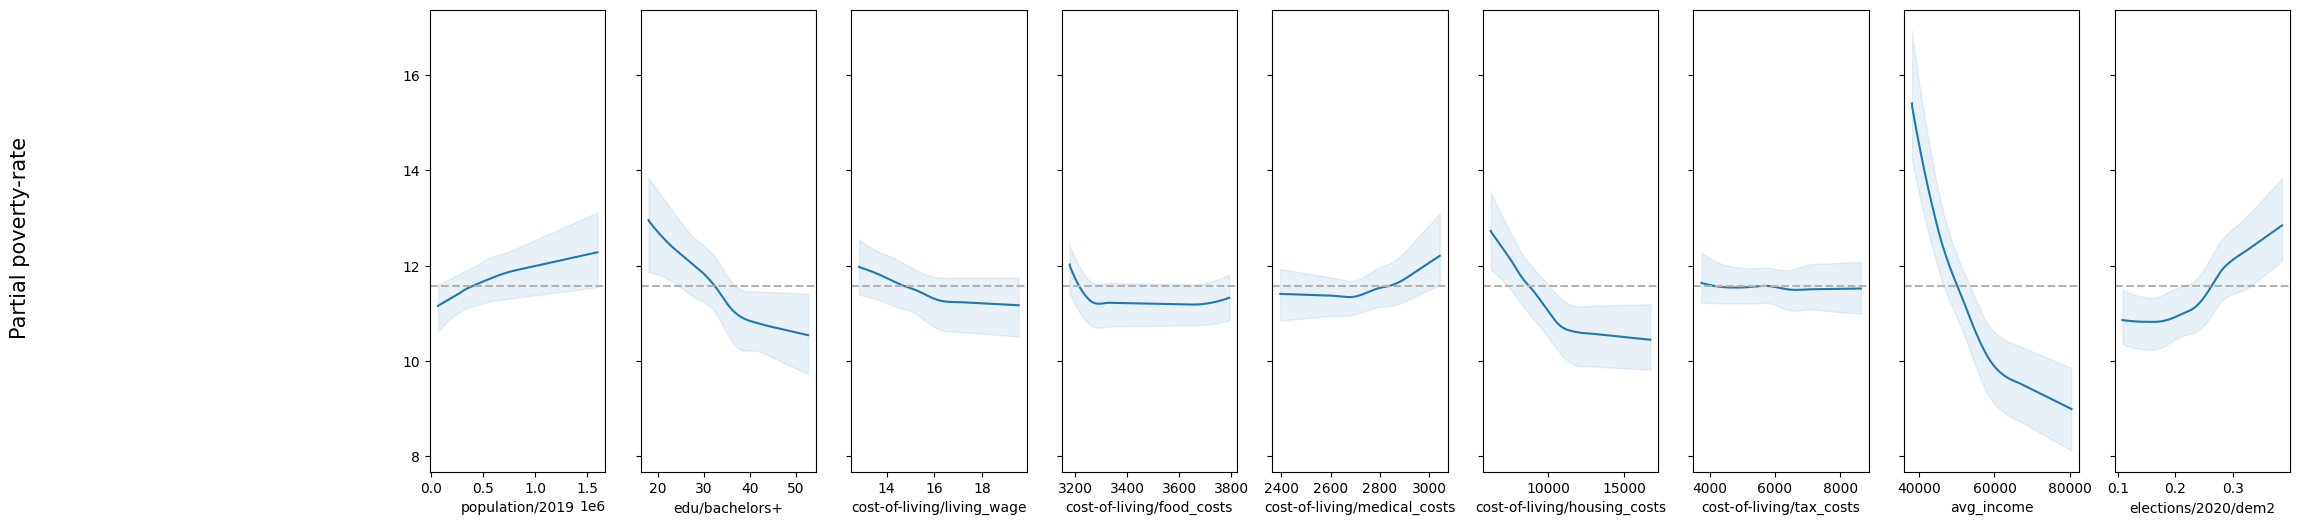

In [ ]:
pmb.plot_pdp(μ_, X, Y, grid=(1,9), func=np.exp, figsize = (24,6))

Here are my ice plots; there's a lot of interesting stuff going on here.
Population stops having much effect after the very low amount, and most other variables taper off at some point.

array([<Axes: xlabel='population/2019'>, <Axes: xlabel='edu/bachelors+'>,
       <Axes: xlabel='cost-of-living/living_wage'>,
       <Axes: xlabel='cost-of-living/food_costs'>,
       <Axes: xlabel='cost-of-living/medical_costs'>,
       <Axes: xlabel='cost-of-living/housing_costs'>,
       <Axes: xlabel='cost-of-living/tax_costs'>,
       <Axes: xlabel='avg_income'>, <Axes: xlabel='elections/2020/dem2'>],
      dtype=object)

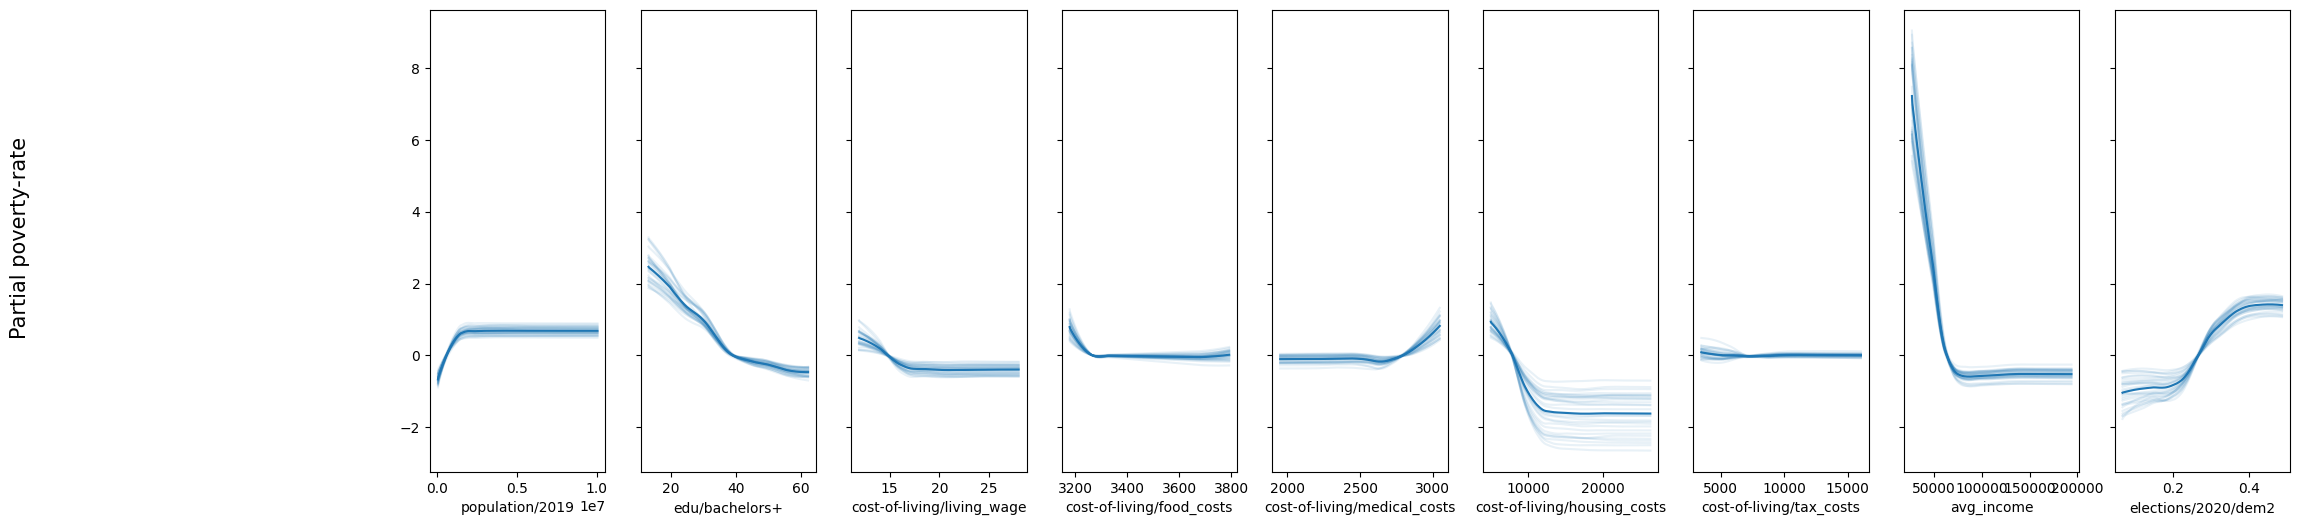

In [ ]:
pmb.plot_ice( μ_, X, Y, grid=(1, 9), func=np.exp, figsize = (24,6))

In [ ]:
vi_counties = pmb.compute_variable_importance(idata_counties, μ_, X)

<Axes: ylabel='R²'>

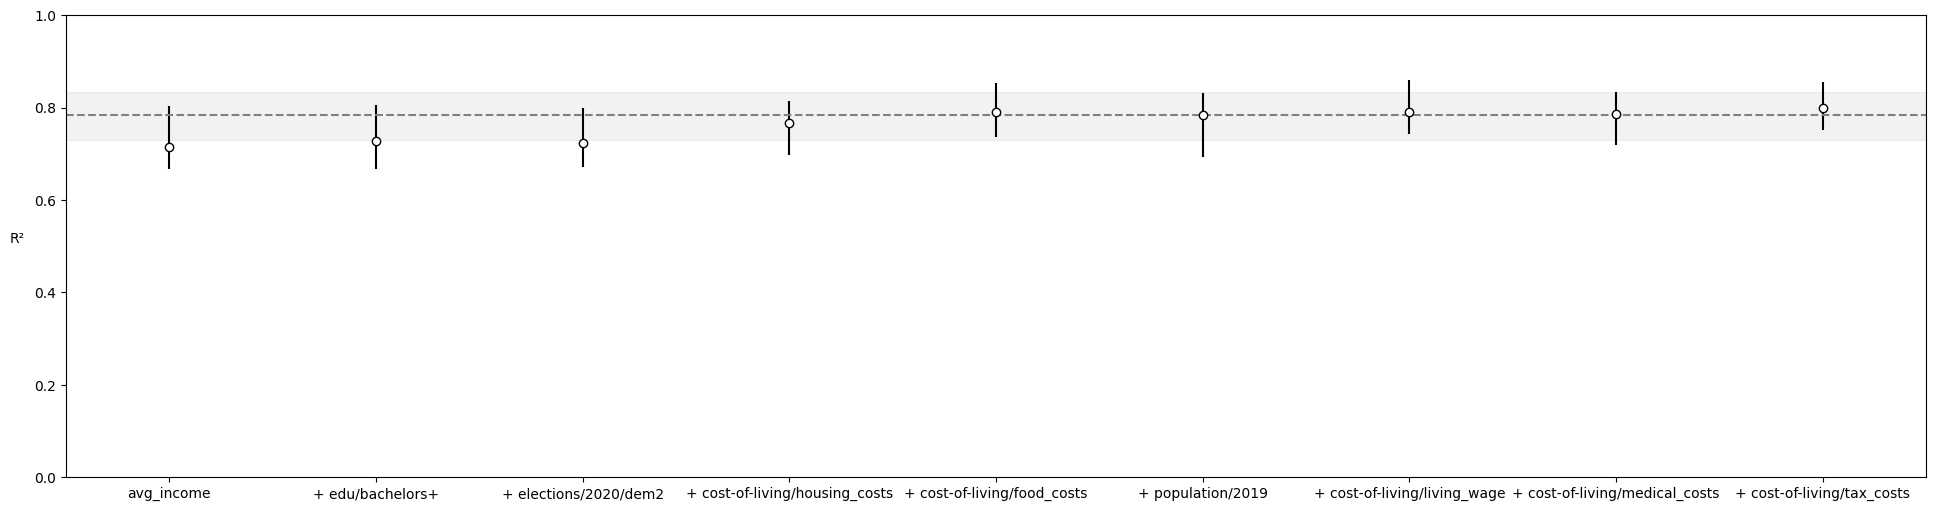

In [ ]:
pmb.plot_variable_importance(vi_counties,figsize=(24,6)) # embiggened